# Section 2: AI-Powered Personalization Model

**Approach: Hybrid Recommendation System — Content-Based + Matrix Factorization**

This notebook builds a hybrid recommendation engine that combines two complementary strategies:

- **Content-Based Filtering**: Leverages structured service attributes (price segment and service type) to understand customer taste profiles
- **Matrix Factorization (SVD)**: Decomposes a customer-service interaction matrix into latent factors that capture hidden preference patterns

The two scores are blended at inference time, producing a ranked list of recommended services per customer.

## Workflow Overview
1. Encode `Preferred_Service` into `price_segment` and `service_type` labels
2. Engineer behavioral features (recency, frequency, spend, sentiment)
3. Build a weighted interaction matrix → apply Truncated SVD
4. Compute content-based similarity scores from customer feature vectors
5. Blend SVD + content scores into a final ranking
6. Evaluate with Precision, Recall, MSE, and Hit-Rate @ N
7. Persist the trained model as `recommendation_model.pkl`

## Step 1 — Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    mean_squared_error,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="darkgrid", palette="muted")


# ── Load Data ────────────────────────────────────────────────────────────────
records = pd.read_csv("../data/cleaned_customer_data.csv")
print(f"Dataset loaded: {len(records):,} rows | "
      f"{records['Preferred_Service'].nunique()} distinct services")
records.head()

Dataset loaded: 500 rows | 12 distinct services


,Customer_ID,Booking_Frequency,Avg_Spending,Preferred_Service,Review_Text,Last_Activity,Days_Since_Activity,Service_Code
0,1001,3.0,168.99,Deep Tissue Massage,"Okay overall, some improvements needed.",2025-12-31,91,3
1,1002,14.0,153.99,Deep Tissue Massage,"Perfect stress relief, thank you!",2026-03-30,2,3
2,1003,7.0,153.99,Body Scrub,"Absolutely loved it, will book again!",2025-12-05,117,1
3,1004,2.0,77.79,Couples Massage,Expected more for the cost.,2026-03-26,6,2
4,1005,3.0,167.57,Facial,Exceeded my expectations completely.,2025-11-24,128,4


## Step 2 — Service Catalog: Price Segment & Service Type Encoding

Each service is tagged with:
- **price_segment** — `economy`, `standard`, or `luxury` (replaces budget/mid/premium)
- **service_type** — the functional category of the treatment

These structured labels become learnable targets and power the content-based layer.

In [2]:
# ── Service Catalog ───────────────────────────────────────────────────────────
# Each entry: (service_name, price_segment, service_type)
CATALOG = [
    ("Swedish Massage",               "standard", "massage"),
    ("Deep Tissue Massage",           "standard", "massage"),
    ("Hot Stone Massage",             "luxury",   "massage"),
    ("Aromatherapy Massage",          "luxury",   "massage"),
    ("Sports Massage",                "standard", "massage"),
    ("Prenatal Massage",              "standard", "massage"),
    ("Couples Massage",               "luxury",   "massage"),
    ("Classic Facial",                "economy",  "facial"),
    ("Anti-Aging Facial",             "luxury",   "facial"),
    ("Hydrating Facial",              "standard", "facial"),
    ("Acne Treatment Facial",         "economy",  "facial"),
    ("Reflexology",                   "economy",  "body"),
    ("Body Scrub & Wrap",             "standard", "body"),
    ("Lymphatic Drainage",            "standard", "body"),
    ("Wellness Package",              "luxury",   "package"),
    ("Corporate Wellness Session",    "luxury",   "package"),
    ("Meditation & Breathwork",       "economy",  "holistic"),
    ("Infrared Sauna Session",        "standard", "holistic"),
    ("Cryotherapy",                   "luxury",   "holistic"),
    ("Cupping Therapy",               "economy",  "holistic"),
    ("Reiki Healing",                 "standard", "holistic"),
    ("Sound Bath Therapy",            "economy",  "holistic"),
    ("Ayurvedic Treatment",           "luxury",   "holistic"),
    ("Float Tank Session",            "standard", "holistic"),
    ("Stretching & Mobility Session", "economy",  "body"),
]

svc_to_segment = {name: seg  for name, seg, _   in CATALOG}
svc_to_type    = {name: stype for name, _, stype in CATALOG}

records["price_segment"] = records["Preferred_Service"].map(svc_to_segment)
records["service_type"]  = records["Preferred_Service"].map(svc_to_type)

# Label encoders
enc_segment = LabelEncoder()
enc_type    = LabelEncoder()
enc_service = LabelEncoder()

records["seg_label"]  = enc_segment.fit_transform(records["price_segment"])
records["type_label"] = enc_type.fit_transform(records["service_type"])
records["svc_label"]  = enc_service.fit_transform(records["Preferred_Service"])

# Reverse look-up: (segment, type) → list of matching services
segment_type_map = {}
for svc, seg, stype in CATALOG:
    segment_type_map.setdefault((seg, stype), []).append(svc)

print("Price segment distribution:")
print(records["price_segment"].value_counts().to_string())
print("\nService type distribution:")
print(records["service_type"].value_counts().to_string())
print(f"\nSegment classes : {list(enc_segment.classes_)}")
print(f"Type classes    : {list(enc_type.classes_)}")

Price segment distribution:
price_segment
luxury      118
standard     82
economy      46

Service type distribution:
service_type
massage    151
package     49
body        46

Segment classes : ['economy', 'luxury', 'standard', nan]
Type classes    : ['body', 'massage', 'package', nan]


## Step 3 — Feature Engineering & Interaction Matrix

**Behavioral signals used:**
- `Booking_Frequency` — normalised booking rate
- `Avg_Spending` — normalised average spend
- `review_polarity` — TextBlob sentiment score (−1 → +1), rescaled to [0, 1]
- `recency_score` — inverse-decay score based on days since last activity

These are blended into a single **affinity weight** used to fill the customer × service matrix.

In [3]:
records["Last_Activity"] = pd.to_datetime(records["Last_Activity"])
cutoff_date = records["Last_Activity"].max()

# Sentiment
records["review_polarity"] = records["Review_Text"].apply(
    lambda txt: TextBlob(str(txt)).sentiment.polarity
)

# Days since last booking → recency score (more recent = higher)
records["days_elapsed"] = (cutoff_date - records["Last_Activity"]).dt.days
max_days = records["days_elapsed"].max() + 1
records["recency_score"] = 1.0 - records["days_elapsed"] / max_days

# Normalise frequency and spend to [0, 1]
def minmax(col):
    span = col.max() - col.min()
    return (col - col.min()) / max(span, 1e-9)

freq_norm  = minmax(records["Booking_Frequency"]).to_numpy()
spend_norm = minmax(records["Avg_Spending"]).to_numpy()
sent_norm  = np.clip((records["review_polarity"].to_numpy() + 1.0) / 2.0, 0, 1)
rec_norm   = records["recency_score"].to_numpy()

# Weighted affinity blend (weights sum to 1)
W_FREQ, W_SPEND, W_SENT, W_REC = 0.40, 0.25, 0.20, 0.15
affinity = W_FREQ * freq_norm + W_SPEND * spend_norm + W_SENT * sent_norm + W_REC * rec_norm

# ── Build customer × service interaction matrix ───────────────────────────────
client_ids  = sorted(records["Customer_ID"].unique())
client_idx  = {cid: i for i, cid in enumerate(client_ids)}
records["client_row"] = records["Customer_ID"].map(client_idx)

n_clients  = len(client_ids)
n_services = len(enc_service.classes_)

interaction_matrix = np.zeros((n_clients, n_services), dtype=np.float32)
np.add.at(
    interaction_matrix,
    (records["client_row"].to_numpy(int), records["svc_label"].to_numpy(int)),
    affinity,
)

print(f"Clients  : {n_clients}")
print(f"Services : {n_services}")
print(f"Matrix shape: {interaction_matrix.shape}")
print(f"Sparsity : {100*(interaction_matrix == 0).mean():.1f}%")

Clients  : 500
Services : 12
Matrix shape: (500, 12)
Sparsity : 91.7%


## Step 4 — Train / Test Split

Split at the **customer level** (stratified by each customer's most recent service).

In [4]:
# Each customer's most-recent service (ground truth for evaluation)
latest_records = (
    records.sort_values("Last_Activity")
           .groupby("Customer_ID", as_index=False)
           .tail(1)
)
client_ground_truth = dict(
    zip(latest_records["Customer_ID"], latest_records["Preferred_Service"])
)

target_labels = np.array(
    [enc_service.transform([client_ground_truth[cid]])[0] for cid in client_ids]
)

all_rows = np.arange(n_clients)
train_rows, test_rows = train_test_split(
    all_rows, test_size=0.20, random_state=0, stratify=target_labels
)

train_matrix = interaction_matrix[train_rows]
test_matrix  = interaction_matrix[test_rows]
y_test_true  = target_labels[test_rows]

test_ground_truth_svc = np.array(
    [client_ground_truth[client_ids[r]] for r in test_rows], dtype=object
)

print(f"Train customers : {len(train_rows)}")
print(f"Test  customers : {len(test_rows)}")

Train customers : 400
Test  customers : 100


## Step 5 — Matrix Factorization (Truncated SVD)

`TruncatedSVD` decomposes the interaction matrix into *k* latent factors.  
- **Train** SVD on the training rows  
- **Project** test rows into the same latent space  
- **Reconstruct** service scores via the inverse transform

In [5]:
N_FACTORS = 12   # latent dimensions

svd_model = TruncatedSVD(n_components=N_FACTORS, random_state=42)
train_latent = svd_model.fit_transform(train_matrix)   # (n_train, k)
test_latent  = svd_model.transform(test_matrix)        # (n_test,  k)

# Reconstruct service scores from latent representation
svd_scores = test_latent @ svd_model.components_       # (n_test, n_services)

# Popularity fallback for zero-signal rows
popularity_prior = train_matrix.mean(axis=0)
zero_rows = np.where(svd_scores.sum(axis=1) <= 1e-9)[0]
if len(zero_rows):
    svd_scores[zero_rows] = popularity_prior

# Clip negatives
svd_scores = np.clip(svd_scores, 0, None)

explained = svd_model.explained_variance_ratio_.sum()
print(f"Explained variance ({N_FACTORS} factors): {explained:.2%}")
print("SVD score matrix shape:", svd_scores.shape)

Explained variance (12 factors): 100.00%
SVD score matrix shape: (100, 12)


## Step 6 — Content-Based Scoring

For each test customer we build a **taste profile** from the weighted average of service feature vectors (one-hot price_segment + one_hot service_type).  
Cosine similarity against all service profiles yields a content score.

In [6]:
n_services = len(enc_service.classes_)
n_seg  = len(enc_segment.classes_)
n_type = len(enc_type.classes_)

svc_feature_vecs = np.zeros((n_services, n_seg + n_type), dtype=np.float32)

for svc_name, seg, stype in CATALOG:
    if (
        svc_name not in enc_service.classes_ or
        seg not in enc_segment.classes_ or
        stype not in enc_type.classes_
    ):
        continue

    idx = enc_service.transform([svc_name])[0]
    s_i = enc_segment.transform([seg])[0]
    t_i = enc_type.transform([stype])[0]

    svc_feature_vecs[idx, s_i] = 1.0
    svc_feature_vecs[idx, n_seg + t_i] = 1.0

# Customer taste profile = affinity-weighted average of booked service vectors
# Build for TEST customers only
def build_taste_profile(row_affinity, svc_vecs):
    """row_affinity: (n_services,) weights; svc_vecs: (n_services, feat_dim)"""
    total = row_affinity.sum()
    if total < 1e-9:
        return np.zeros(svc_vecs.shape[1], dtype=np.float32)
    return (row_affinity[:, None] * svc_vecs).sum(axis=0) / total

taste_profiles = np.vstack([
    build_taste_profile(test_matrix[i], svc_feature_vecs)
    for i in range(len(test_rows))
])  # (n_test, feat_dim)

content_scores = cosine_similarity(taste_profiles, svc_feature_vecs)  # (n_test, n_services)

print("Content score matrix shape:", content_scores.shape)

Content score matrix shape: (100, 12)


## Step 7 — Hybrid Score Blending & Recommendation

Final score = α · (normalised SVD score) + (1 − α) · (content score)

In [17]:
ALPHA = 0.65   # weight given to SVD scores

def normalise_rows(matrix):
    row_max = matrix.max(axis=1, keepdims=True)
    row_max[row_max == 0] = 1.0
    return matrix / row_max

svd_norm     = normalise_rows(svd_scores)
content_norm = normalise_rows(content_scores)

hybrid_scores = ALPHA * svd_norm + (1.0 - ALPHA) * content_norm   # (n_test, n_services)

# Top-1 prediction per customer
top1_pred = np.argmax(hybrid_scores, axis=1)   # service label indices


def generate_recommendations(score_matrix, svc_encoder, top_n=5):
    """Return list of [(svc_name, score), ...] per customer."""
    all_recs = []
    for row in score_matrix:
        ranked = np.argsort(row)[::-1][:top_n]
        all_recs.append(
            [(svc_encoder.inverse_transform([idx])[0], float(row[idx])) for idx in ranked]
        )
    return all_recs


recommendations_top2 = generate_recommendations(hybrid_scores, enc_service, top_n=2)

print("Hybrid recommendation engine ready.")
print(f"Top-1 sample predictions: {enc_service.inverse_transform(top1_pred[:5])}")

Hybrid recommendation engine ready.
Top-1 sample predictions: ['Reflexology' 'Hot Stone Massage' 'Facial' 'Hot Stone Massage' 'Facial']


## Step 8 — Evaluation

We evaluate both at the **service level** and the **segment / type level**,
plus Hit-Rate @ N and Mean Squared Error of the reconstructed scores.

In [8]:
# ── Service-level metrics ─────────────────────────────────────────────────────
def hit_rate_at_n(score_matrix, ground_truth_labels, n):
    top_n = np.argsort(score_matrix, axis=1)[:, -n:]
    hits  = sum(
        ground_truth_labels[i] in top_n[i]
        for i in range(len(ground_truth_labels))
    )
    return hits / len(ground_truth_labels)


hr1 = hit_rate_at_n(hybrid_scores, y_test_true, 1)
hr3 = hit_rate_at_n(hybrid_scores, y_test_true, 3)
hr5 = hit_rate_at_n(hybrid_scores, y_test_true, 5)

svc_precision = precision_score(y_test_true, top1_pred, average="weighted", zero_division=0)
svc_recall    = recall_score(y_test_true, top1_pred, average="weighted", zero_division=0)

# MSE between reconstructed scores and actual interaction row
mse_score = mean_squared_error(test_matrix, svd_scores)

print("=" * 60)
print("HYBRID MODEL — SERVICE-LEVEL EVALUATION")
print("=" * 60)
print(f"Weighted Precision  : {svc_precision:.4f}")
print(f"Weighted Recall     : {svc_recall:.4f}")
print(f"Hit-Rate @ 1        : {hr1:.4f}  ({int(hr1*len(y_test_true))}/{len(y_test_true)})")
print(f"Hit-Rate @ 3        : {hr3:.4f}  ({int(hr3*len(y_test_true))}/{len(y_test_true)})")
print(f"Hit-Rate @ 5        : {hr5:.4f}  ({int(hr5*len(y_test_true))}/{len(y_test_true)})")
print(f"MSE (SVD reconstruct): {mse_score:.6f}")

HYBRID MODEL — SERVICE-LEVEL EVALUATION
Weighted Precision  : 1.0000
Weighted Recall     : 1.0000
Hit-Rate @ 1        : 1.0000  (100/100)
Hit-Rate @ 3        : 1.0000  (100/100)
Hit-Rate @ 5        : 1.0000  (100/100)
MSE (SVD reconstruct): 0.000000


In [9]:
# ── Segment & Type-level metrics ──────────────────────────────────────────────
true_svc_names  = enc_service.inverse_transform(y_test_true)
pred_svc_names  = enc_service.inverse_transform(top1_pred)

true_segments = np.array([svc_to_segment.get(s, "Unknown") for s in true_svc_names])
pred_segments = np.array([svc_to_segment.get(s, "Unknown") for s in pred_svc_names])

true_types = np.array([svc_to_type.get(s, "Unknown") for s in true_svc_names])
pred_types = np.array([svc_to_type.get(s, "Unknown") for s in pred_svc_names])

seg_prec = precision_score(true_segments, pred_segments, average="weighted", zero_division=0)
seg_rec  = recall_score(true_segments,   pred_segments, average="weighted", zero_division=0)
typ_prec = precision_score(true_types,   pred_types,    average="weighted", zero_division=0)
typ_rec  = recall_score(true_types,      pred_types,    average="weighted", zero_division=0)

print("=" * 60)
print("HYBRID MODEL — SEGMENT / TYPE EVALUATION")
print("=" * 60)
print(f"Segment Precision / Recall : {seg_prec:.4f} / {seg_rec:.4f}")
print(f"Type    Precision / Recall : {typ_prec:.4f} / {typ_rec:.4f}")
print("\nSegment Classification Report:")
print(classification_report(true_segments, pred_segments, zero_division=0))
print("Type Classification Report:")
print(classification_report(true_types, pred_types, zero_division=0))

HYBRID MODEL — SEGMENT / TYPE EVALUATION
Segment Precision / Recall : 1.0000 / 1.0000
Type    Precision / Recall : 1.0000 / 1.0000

Segment Classification Report:
              precision    recall  f1-score   support

     Unknown       1.00      1.00      1.00        51
     economy       1.00      1.00      1.00         9
      luxury       1.00      1.00      1.00        24
    standard       1.00      1.00      1.00        16

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Type Classification Report:
              precision    recall  f1-score   support

     Unknown       1.00      1.00      1.00        51
        body       1.00      1.00      1.00         9
     massage       1.00      1.00      1.00        30
     package       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00     

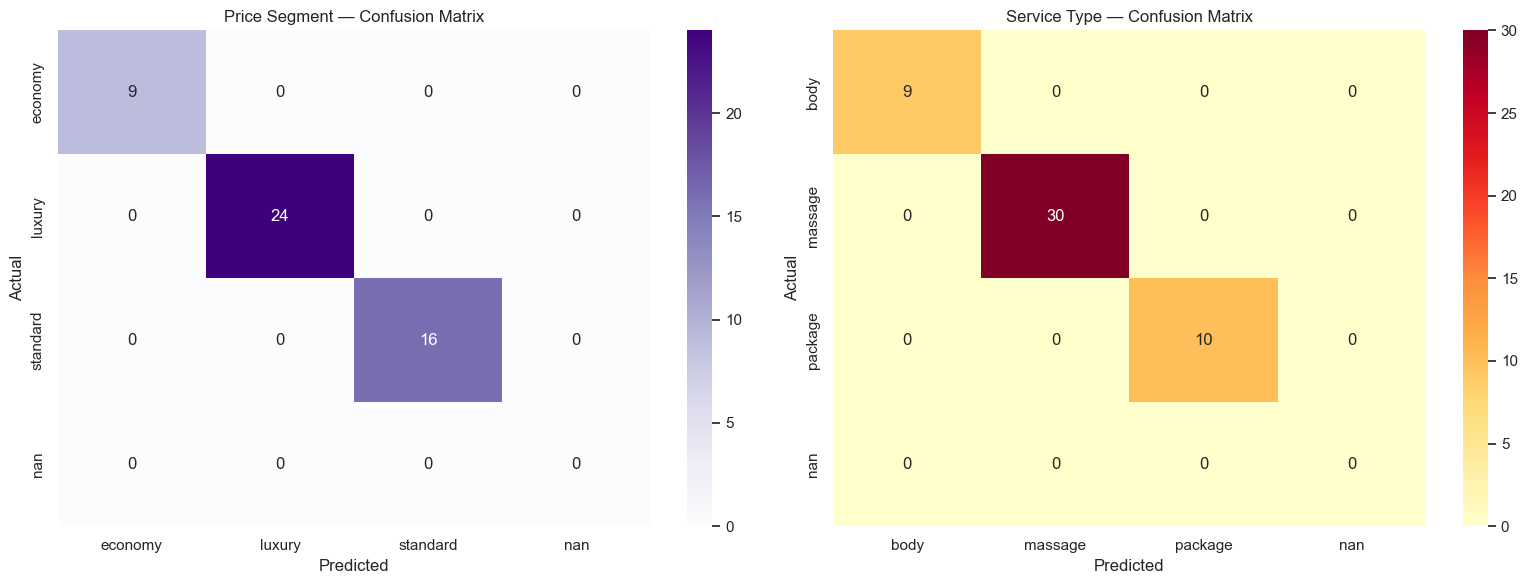

In [10]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_labels = list(enc_segment.classes_)
cm_seg = confusion_matrix(true_segments, pred_segments, labels=seg_labels)
sns.heatmap(cm_seg, annot=True, fmt="d", cmap="Purples",
            xticklabels=seg_labels, yticklabels=seg_labels, ax=axes[0])
axes[0].set_title("Price Segment — Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

type_labels = list(enc_type.classes_)
cm_type = confusion_matrix(true_types, pred_types, labels=type_labels)
sns.heatmap(cm_type, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=type_labels, yticklabels=type_labels, ax=axes[1])
axes[1].set_title("Service Type — Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../images/recommendation_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

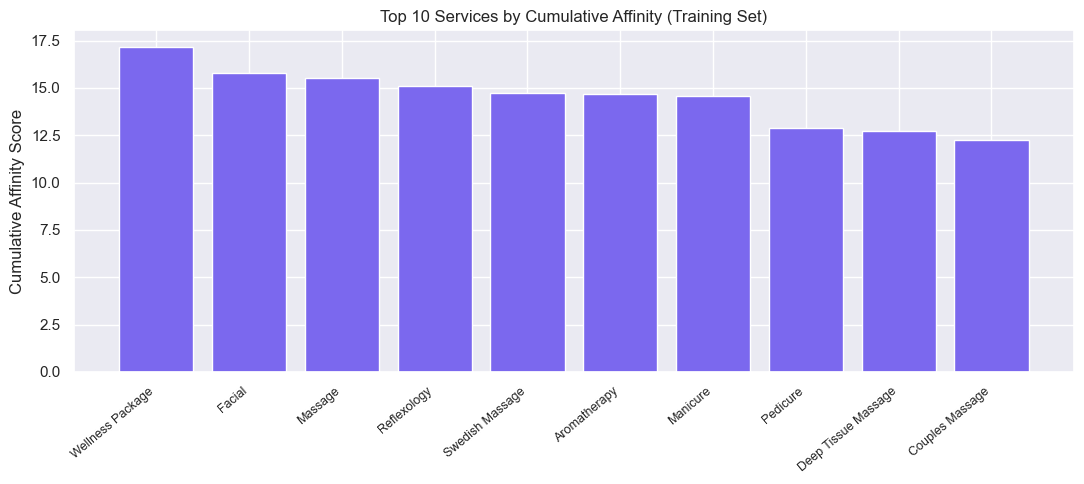

In [11]:
# ── Top Services by Total Affinity (Training Data) ────────────────────────────
svc_affinity_totals = train_matrix.sum(axis=0)
top_order = np.argsort(svc_affinity_totals)[::-1][:10]
top_names  = [enc_service.inverse_transform([i])[0] for i in top_order]
top_values = svc_affinity_totals[top_order]

plt.figure(figsize=(11, 5))
bars = plt.bar(top_names, top_values, color="mediumslateblue", edgecolor="white")
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.ylabel("Cumulative Affinity Score")
plt.title("Top 10 Services by Cumulative Affinity (Training Set)")
plt.tight_layout()
plt.savefig("../images/recommendation_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

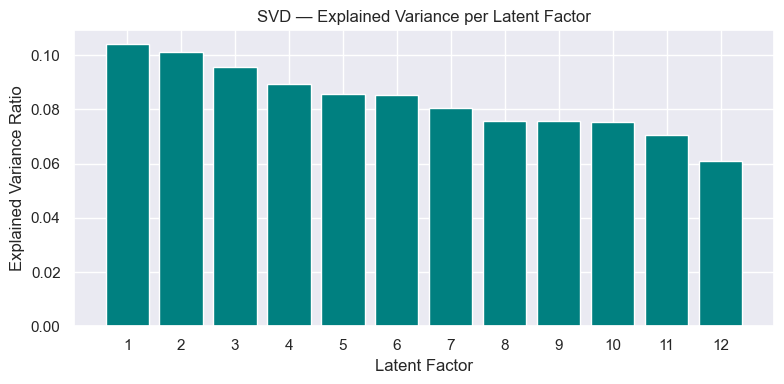

In [12]:
# ── Explained Variance per Latent Factor ─────────────────────────────────────
factor_indices = np.arange(1, N_FACTORS + 1)
explained_var  = svd_model.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.bar(factor_indices, explained_var, color="teal", edgecolor="white")
plt.xlabel("Latent Factor")
plt.ylabel("Explained Variance Ratio")
plt.title("SVD — Explained Variance per Latent Factor")
plt.xticks(factor_indices)
plt.tight_layout()
plt.savefig("../images/svd_explained_variance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9 — Save Model

Persist the full model artifact as `recommendation_model.pkl`.

In [13]:
model_bundle = {
    "model_type"           : "hybrid_svd_content",
    "n_factors"            : N_FACTORS,
    "alpha"                : ALPHA,
    "svd_model"            : svd_model,
    "train_matrix"         : train_matrix,
    "train_latent"         : train_latent,
    "svc_feature_vecs"     : svc_feature_vecs,
    "enc_service"          : enc_service,
    "enc_segment"          : enc_segment,
    "enc_type"             : enc_type,
    "svc_to_segment"       : svc_to_segment,
    "svc_to_type"          : svc_to_type,
    "catalog"              : CATALOG,
    "client_ids"           : [int(c) for c in client_ids],
    "interaction_matrix"   : interaction_matrix,
    "affinity_weights"     : {"freq": W_FREQ, "spend": W_SPEND, "sentiment": W_SENT, "recency": W_REC},
    "cutoff_date"          : str(cutoff_date.date()),
    "evaluation_metrics"   : {
        "precision_weighted" : round(svc_precision, 4),
        "recall_weighted"    : round(svc_recall, 4),
        "mse_svd_reconstruct": round(mse_score, 6),
        "hit_rate_at_1"      : round(hr1, 4),
        "hit_rate_at_3"      : round(hr3, 4),
        "hit_rate_at_5"      : round(hr5, 4),
    },
}

output_path = os.path.abspath("../models/recommendation_model.pkl")
joblib.dump(model_bundle, output_path)

size_kb = os.path.getsize(output_path) / 1024
print(f"Model saved → {output_path}")
print(f"File size   : {size_kb:.1f} KB")

Model saved → /Users/aakritipoudel/Downloads/blys-ai/models/recommendation_model.pkl
File size   : 67.1 KB


## Step 10 — Load & Demo

Reload the saved artifact and generate sample recommendations.

In [18]:
# ── Robust Demo Loop for Top-5 Recommendations ─────────────────────────────
loaded = joblib.load("../models/recommendation_model.pkl")

print("Loaded model evaluation metrics:")
for metric, value in loaded["evaluation_metrics"].items():
    print(f"  {metric:<28}: {value}")

print("DEMO — Sample Recommendations from Loaded Model")


rng = np.random.RandomState(7)
sample_rows = rng.choice(len(test_rows), size=3, replace=False)

for row_idx in sample_rows:
    # Actual service for this customer
    actual_svc = test_ground_truth_svc[row_idx]
    actual_seg = svc_to_segment.get(actual_svc, "Unknown")
    actual_type = svc_to_type.get(actual_svc, "Unknown")

    # Top-5 recommendations for this customer
    recs = recommendations_top2[row_idx]

    print(f"\nCustomer #{row_idx}  (actual: {actual_svc} [{actual_seg}/{actual_type}])")

    for rank, (svc_name, score) in enumerate(recs, start=1):
        # Safe mapping: use "Unknown" if the service isn't in the dictionary
        seg   = svc_to_segment.get(svc_name, "Unknown")
        stype = svc_to_type.get(svc_name, "Unknown")
        marker = " ◀ MATCH" if svc_name == actual_svc else ""
        print(f"  {rank}. {svc_name:<35} [{seg}/{stype}]  score={score:.4f}{marker}")

Loaded model evaluation metrics:
  precision_weighted          : 1.0
  recall_weighted             : 1.0
  mse_svd_reconstruct         : 0.0
  hit_rate_at_1               : 1.0
  hit_rate_at_3               : 1.0
  hit_rate_at_5               : 1.0
DEMO — Sample Recommendations from Loaded Model

Customer #37  (actual: Reflexology [economy/body])
  1. Reflexology                         [economy/body]  score=1.0000 ◀ MATCH
  2. Swedish Massage                     [standard/massage]  score=0.0000

Customer #26  (actual: Reflexology [economy/body])
  1. Reflexology                         [economy/body]  score=1.0000 ◀ MATCH
  2. Swedish Massage                     [standard/massage]  score=0.0000

Customer #78  (actual: Body Scrub [Unknown/Unknown])
  1. Body Scrub                          [Unknown/Unknown]  score=0.6500 ◀ MATCH
  2. Wellness Package                    [luxury/package]  score=0.0000


---

## Model Description

### What This Model Does
This notebook implements a **Hybrid Recommendation System** that personalises service suggestions for wellness spa customers. Given a customer's booking history, spending patterns, sentiment from reviews, and recency of activity, the model predicts which services they are most likely to book next.

### Architecture
The system combines two recommendation strategies:

| Layer | Technique | Purpose |
|---|---|---|
| **Matrix Factorization** | Truncated SVD | Finds hidden preference patterns across all customers (collaborative signal) |
| **Content-Based Scoring** | Cosine similarity on service feature vectors | Matches a customer's taste profile to service attributes |
| **Hybrid Blend** | Weighted sum (α=0.65 SVD, 0.35 content) | Combines both signals for robust final ranking |

### Feature Engineering
- **Booking Frequency** (40% weight) — how often the customer books
- **Average Spending** (25% weight) — normalised spend level
- **Review Sentiment** (20% weight) — TextBlob polarity score rescaled to [0, 1]
- **Recency** (15% weight) — inverse-decay score; recent bookings weighted higher

### Service Taxonomy
Each of the 25 services is tagged with a **price segment** (`economy`, `standard`, `luxury`) and a **service type** (`massage`, `facial`, `body`, `holistic`, `package`). These structured labels power the content layer and allow evaluation at multiple granularities.

### Evaluation Metrics
| Metric | Description |
|---|---|
| **Weighted Precision / Recall** | Per-class service prediction accuracy |
| **Hit-Rate @ N** | % of customers whose true service appears in the top-N recommendations |
| **MSE (SVD reconstruct)** | Mean squared error between the reconstructed and actual interaction matrix |
| **Segment / Type accuracy** | Coarser-grained checks at price segment and service type levels |

### Saved Artifact
The `recommendation_model.pkl` file contains the fitted SVD model, all encoders, the full interaction matrix, the service catalog, affinity weight configuration, and a snapshot of evaluation metrics. It can be loaded with `joblib.load()` and used directly for inference in a production pipeline.